# Thống kê suy diễn

## Kiểm Định một mẫu

**Bài toán**: Nhiều nguồn tin cho rằng tốc độ lõi (Core_Speed) trung bình của GPU hãng NVIDIA lớn hơn mức tiêu chuẩn 950 MHz, hãy tiến hành kiểm định giả thuyết này có đúng hay không với mức ý nghĩa là 5%.

In [ ]:
nvidia_coreSpeed <- subset(gpu_clean, Manufacturer == "Nvidia")$Core_Speed
print("Mẫu core speed của Nvidia")
str(nvidia_coreSpeed)

[1] "Mẫu core speed của Nvidia"
 int [1:1614] 738 650 705 706 980 732 575 575 575 980 ...


**1. Xác định trường hợp**
- Kiểm tra mẫu có phân phối chuẩn không bằng hai phương pháp là biểu đồ Q-Q và  Shapiro-Wilk
- Kiểm tra xem số lượng mẫu có đủ lớn $n > 30$ không. 

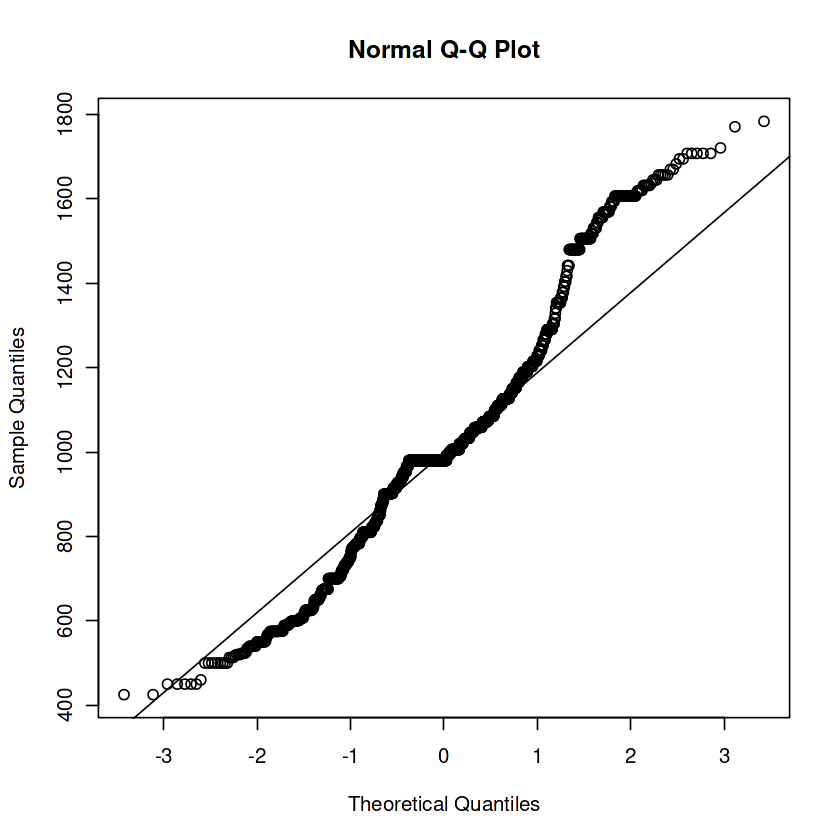

In [ ]:
print("vẽ biểu đồ Q-Q kiểm tra phân phối chuẩn")
qqnorm(nvidia_coreSpeed)
qqline(nvidia_coreSpeed)

- Quan sát biểu đồ Q-Q Plot, ta thấy phần lớn các điểm phân vị của dữ liệu thực tế bị lệch khỏi đường thẳng chuẩn. Điều này cho thấy dữ liệu không có hình dạng phân phối chuẩn.

In [ ]:
print("shapiro test kiểm tra phân phối chuẩn")
shapiro.test(nvidia_coreSpeed)


	Shapiro-Wilk normality test

data:  nvidia_coreSpeed
W = 0.96384, p-value < 2.2e-16


- Kết quả kiểm định Shapiro-Wilk cho giá trị thống kê $W = 0.96384$ và $p\text{-value} < 2.2 \times 10^{-16}$.

- Vì $p\text{-value}$ rất nhỏ (nhỏ hơn mức ý nghĩa $\alpha = 0.05$), ta bác bỏ giả thuyết $H_0$ của kiểm định Shapiro, khẳng định tập dữ liệu nvidia_coreSpeed không tuân theo phân phối chuẩn.

In [51]:
n <- length(nvidia_coreSpeed)
cat("Kích thước mẫu là:", n)

Kích thước mẫu là: 1614

- Mặc dù tổng thể không có phân phối chuẩn, nhưng tập dữ liệu Nvidia có kích thước mẫu là $n = 1614$.

- Vì $n = 1614 \gg 30$, theo Định lý Giới hạn Trung tâm (Central Limit Theorem), phân phối của trung bình mẫu sẽ xấp xỉ phân phối chuẩn.

- Do đó bài toán rơi vào trường hợp tổng thể có phân phối bất kỳ , mẫu lớn, chưa biết phương sai tổng thể.

**2. Đặt giả thuyết thống kê**
 
- Gọi $a$ là tốc độ lõi (Core_Speed) trung bình của GPU hãng NVIDIA.

- Giả thuyết không ($H_0$): $a \leq a_0 = 950$ (Tốc độ lõi trung bình bằng mức tiêu chuẩn 950 MHz).

- Giả thuyết đối ($H_1$): $a > a_0 = 950$ (Tốc độ lõi trung bình lớn hơn mức tiêu chuẩn 950 MHz).

- Đây là bài toán kiểm định một phía (bên phải).

- Mức ý nghĩa: $\alpha = 0.05$.

In [52]:
z_alpha <- qnorm(1 - 0.05)
cat("Xác định miền bác bỏ W: \n")
cat("Giá trị tới hạn z_alpha:", z_alpha, "\n")
cat("Miền bác bỏ: W = (", z_alpha, "; +∞ )\n", sep="")

Xác định miền bác bỏ W: 
Giá trị tới hạn z_alpha: 1.644854 
Miền bác bỏ: W = (1.644854; +∞ )


**3. Tính toán giá trị kiểm định**


Công thức tính giá trị kiểm định $U_{qs}$:$$U_{qs} = \frac{\overline{x} - a_0}{\frac{s}{\sqrt{n}}}$$

In [53]:
x_bar <- mean(nvidia_coreSpeed)
s <- sd(nvidia_coreSpeed)
n <- length(nvidia_coreSpeed)
a0 <- 950


Uqs <- (x_bar - a0) / (s / sqrt(n))


cat("Trung bình mẫu (x_bar):", x_bar, "\n")
cat("Độ lệch chuẩn (s):", s, "\n")
cat("Kích thước mẫu (n):", n, "\n")
cat("Giá trị kiểm định Uqs:", Uqs, "\n")

Trung bình mẫu (x_bar): 1014.186 
Độ lệch chuẩn (s): 258.3767 
Kích thước mẫu (n): 1614 
Giá trị kiểm định Uqs: 9.980264 


**4. Kết luận**

- Ta có giá trị kiểm định tính được: $U_{qs} = 9.9803$.
- Miền bác bỏ đã xác định ở Bước 1: $W = (1.6449; +\infty)$.
- Nhận thấy $U_{qs} = 9.9803 > 1.6449$, tức là giá trị kiểm định thuộc vào miền bác bỏ. Ở mức ý nghĩa 5%, chúng ta có đầy đủ bằng chứng thống kê để bác bỏ giả thuyết $H_0$ và chấp nhận giả thuyết đối $H_1$. Điều này khẳng định rằng: Nguồn tin cho rằng tốc độ lõi (Core_Speed) trung bình của các dòng GPU hãng NVIDIA thực sự lớn hơn mức tiêu chuẩn 950 MHz là hoàn toàn có cơ sở và chính xác.

## Kiểm định hai mẫu

**Bài toán**: Trong việc huấn luyện các mô hình trí tuệ nhân tạo (AI Training), dung lượng bộ nhớ đồ họa (VRAM) là một yếu tố then chốt. Có quan điểm cho rằng các dòng GPU của hãng NVIDIA có dung lượng VRAM(Memory) trung bình lớn hơn so với các dòng GPU của hãng AMD. Hãy kiểm định xem liệu quan điểm này có cơ sở thống kê hay không với mức ý nghĩa 5%.

In [ ]:
nvidia_vram <- subset(gpu_clean, Manufacturer == "Nvidia")$Memory

amd_vram <- subset(gpu_clean, Manufacturer == "AMD")$Memory

str(nvidia_vram)

str(amd_vram)



 int [1:1614] 1024 6144 5120 12288 8192 6144 6144 6144 3072 2048 ...
 int [1:1204] 512 512 256 256 256 2048 256 2048 3072 2048 ...


**1. Xác định trường hợp**


- Để xác định trường hợp chúng ta đầu tiên cần xét 3 yếu tố: Phân phối chuẩn, Cỡ mẫu và tính độc lập.

Phân phối và cỡ mẫu được xét tương tự như trong bài toán một mẫu

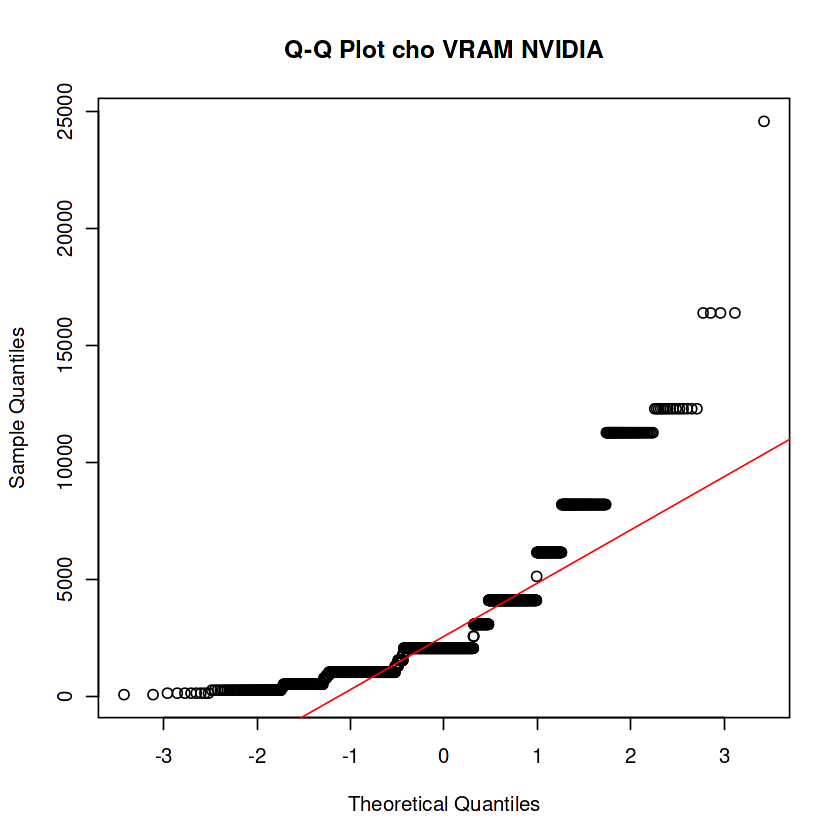

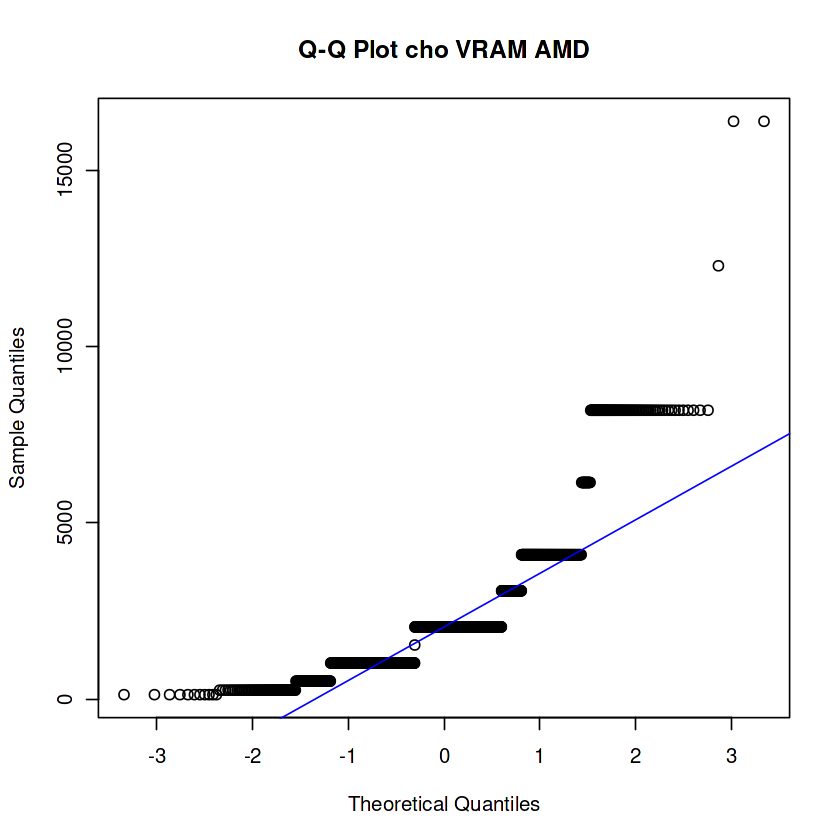

In [ ]:
print("vẽ biểu đồ Q-Q kiểm tra phân phối chuẩn")
qqnorm(nvidia_vram, main = "Q-Q Plot cho VRAM NVIDIA")
qqline(nvidia_vram, col = "red")
qqnorm(amd_vram, main = "Q-Q Plot cho VRAM AMD")
qqline(amd_vram, col = "blue")


In [ ]:
print("shapiro test kiểm tra phân phối chuẩn")
shapiro.test(nvidia_vram)
shapiro.test(amd_vram)


	Shapiro-Wilk normality test

data:  nvidia_vram
W = 0.7847, p-value < 2.2e-16



	Shapiro-Wilk normality test

data:  amd_vram
W = 0.76397, p-value < 2.2e-16


Cả phương pháp đồ thị (Q-Q Plot) và phương pháp kiểm định giả thuyết (Shapiro-Wilk) đều cho thấy dữ liệu VRAM của Nvidia và AMD không có phân phối chuẩn.

In [ ]:
n1 <- length(nvidia_vram)
n2 <- length(amd_vram)
cat("Kích thước mẫu NVIDIA (n1) là:", n1, "\n")
cat("Kích thước mẫu AMD (n2) là:", n2, "\n")

Kích thước mẫu NVIDIA (n1) là: 1614 
Kích thước mẫu AMD (n2) là: 1204 


Do dữ liệu của hai công ty này độc lập và đủ lớn nên đây là trường hợp kiêm thử hai mẫu độc lập , hai tổng thể có phân phối bất kỳ , mẫu lớn ($n \geq 30 $)

**2. Đặt giả thuyết thống kê**
- Gọi $a_{1}$ là dung lượng VRAM (Memory) trung bình của các dòng GPU hãng NVIDIA.
- Gọi $a_{2}$ là dung lượng VRAM (Memory) trung bình của các dòng GPU hãng AMD.
- Giả thuyết không ($H_0$): $a_{1} \le a_{2}$ (Dung lượng VRAM trung bình của NVIDIA không lớn hơn AMD).
- Giả thuyết đối ($H_1$): $a_{1} > a_{2}$ (Dung lượng VRAM trung bình của NVIDIA thực sự lớn hơn AMD).
- Đây là bài toán kiểm định giả thuyết về hiệu hai trung bình tổng thể, loại kiểm định một phía (bên phải).
- Mức ý nghĩa: $\alpha = 0.05$.

In [ ]:
z_alpha <- qnorm(1 - 0.05)

cat("Xác định miền bác bỏ W: \n")
cat("Giá trị tới hạn z_alpha:", z_alpha, "\n")
cat("Miền bác bỏ: W = (",z_alpha, "; +∞ )\n", sep="")

Xác định miền bác bỏ W: 
Giá trị tới hạn z_alpha: 1.644854 
Miền bác bỏ: W = (1.644854; +∞ )


**3. Tính toán giá trị kiểm định**

Ta áp dụng công thức tiêu chuẩn kiểm định $U_{qs}$ cho trường hợp hai mẫu độc lập, cỡ mẫu lớn và chưa biết phương sai tổng thể:
$$U_{qs}= \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$
Trong đó:
- $\bar{x}_1, s_1, n_1$ lần lượt là trung bình, độ lệch chuẩn và kích thước mẫu của NVIDIA.
- $\bar{x}_2, s_2, n_2$ lần lượt là trung bình, độ lệch chuẩn và kích thước mẫu của AMD.

In [ ]:
# Tính toán các đặc trưng mẫu cho NVIDIA 
n1 <- length(nvidia_vram)
x1_bar <- mean(nvidia_vram)
s1 <- sd(nvidia_vram)

# Tính toán các đặc trưng mẫu cho AMD 
n2 <- length(amd_vram)
x2_bar <- mean(amd_vram)
s2 <- sd(amd_vram)

# Tính toán giá trị kiểm định U_{qs}
Uqs <- (x1_bar - x2_bar) / sqrt((s1^2 / n1) + (s2^2 / n2))

# Hiển thị bảng thông số tóm tắt
cat("--- THÔNG SỐ MẪU NVIDIA ---\n")
cat("Kích thước mẫu (n1): ", n1, "\n")
cat("Trung bình (x1_bar):  ", x1_bar, " MB\n")
cat("Độ lệch chuẩn (s1):   ", s1, "\n\n")

cat("--- THÔNG SỐ MẪU AMD ---\n")
cat("Kích thước mẫu (n2): ", n2, "\n")
cat("Trung bình (x2_bar):  ", x2_bar, " MB\n")
cat("Độ lệch chuẩn (s2):   ", s2, "\n\n")

cat("--- KẾT QUẢ TÍNH TOÁN ---\n")
cat("Giá trị kiểm định Uqs: ", Uqs, "\n")

--- THÔNG SỐ MẪU NVIDIA ---
Kích thước mẫu (n1):  1614 
Trung bình (x1_bar):   3066.726  MB
Độ lệch chuẩn (s1):    2786.746 

--- THÔNG SỐ MẪU AMD ---
Kích thước mẫu (n2):  1204 
Trung bình (x2_bar):   2377.887  MB
Độ lệch chuẩn (s2):    2014.549 

--- KẾT QUẢ TÍNH TOÁN ---
Giá trị kiểm định Uqs:  7.615136 


**4. Kết luận**
- Giá trị kiểm định tính được: $U_{qs} \approx 7.6151$, lớn hơn rõ rệt so với giá trị tới hạn $Z_{0.1} \approx 1.6449$.
- Ở mức ý nghĩa 5%, chúng ta có đầy đủ bằng chứng thống kê để bác bỏ giả thuyết $H_0$ và chấp nhận giả thuyết đối $H_1$. Quan điểm cho rằng các dòng GPU của hãng NVIDIA có dung lượng VRAM (Memory) trung bình lớn hơn so với các dòng GPU của hãng AMD là hoàn toàn có cơ sở và chính xác về mặt thống kê. Vì vậy, đối với các tác vụ yêu cầu bộ nhớ đồ họa lớn như huấn luyện mô hình AI, NVIDIA hiện đang cung cấp một mức dung lượng trung bình vượt trội hơn